# Multinomial Naive Bayes (MNB)

# Descripción

Multinomial Naive Bayes (MNB) es un algoritmo de clasificación probabilística basado en el Teorema de Bayes y pertenece a la familia de clasificadores Naive Bayes. Está diseñado principalmente para trabajar con datos discretos representados mediante frecuencias o conteos, siendo ampliamente utilizado en problemas de procesamiento de lenguaje natural (NLP).

El algoritmo considera que la frecuencia de aparición de las características sigue una distribución multinomial. En aplicaciones de texto, las características corresponden generalmente a palabras o términos, y el modelo aprende la probabilidad de que cada palabra aparezca dentro de una determinada clase.

Durante la predicción, Multinomial Naive Bayes calcula la probabilidad posterior de cada clase utilizando la frecuencia de los términos observados y asigna la muestra a la clase con mayor probabilidad.

Debido a su eficiencia, bajo costo computacional y buen desempeño con grandes cantidades de datos textuales, es uno de los algoritmos más utilizados para clasificación de documentos, filtrado de spam y análisis de sentimientos.

# BibTeX y Referencias

1. McCallum, A., & Nigam, K. (1998). *A Comparison of Event Models for Naive Bayes Text Classification*. AAAI Workshop on Learning for Text Categorization, 41–48.

2. Manning, C. D., Raghavan, P., & Schütze, H. (2008). *Introduction to Information Retrieval*. Cambridge University Press.

3. Murphy, K. P. (2012). *Machine Learning: A Probabilistic Perspective*. MIT Press.




# Tipo de Modelo

• **Método de Aprendizaje:** Aprendizaje Supervisado.

• **Tipo por Parámetros:** Modelo Paramétrico.

• **Tipo de Datos de Aprendizaje:** Datos discretos representados mediante conteos o frecuencias.

• **Resultado del Entrenamiento:** Modelo probabilístico basado en la estimación de probabilidades de aparición de características para cada clase.

# Alg. Entrenamiento

**Multinomial Naive Bayes**

Durante el entrenamiento el algoritmo realiza las siguientes etapas:

1. Convierte los datos de entrada en una representación numérica basada en frecuencias o conteos.

2. Calcula la probabilidad a priori de cada clase.

3. Calcula la probabilidad de aparición de cada característica dentro de cada clase.

4. Utiliza la distribución multinomial para modelar la frecuencia de los atributos.

5. Almacena las probabilidades obtenidas para clasificar nuevas observaciones.

# Supuestos y Restricciones

## Supuestos

• Las características son condicionalmente independientes dada la clase.

• La frecuencia de aparición de las características sigue una distribución multinomial.

• La representación de los datos mediante conteos conserva información relevante para la clasificación.

• Los datos de entrenamiento representan adecuadamente la distribución de las clases.

## Restricciones

• No considera el orden de aparición de las palabras dentro del texto.

• Puede perder información semántica del lenguaje.

• Su desempeño depende de la calidad de la representación de los datos.

• La independencia entre características es una aproximación que puede no cumplirse completamente.

# Ventajas

• Entrenamiento rápido y eficiente incluso con grandes volúmenes de datos.

• Bajo costo computacional debido a que solamente estima probabilidades de frecuencia.

• Funciona especialmente bien en problemas de clasificación de texto.

• Requiere poca cantidad de datos para obtener resultados aceptables.

• Es fácil de implementar e interpretar.

• Es ampliamente utilizado como modelo base (baseline) en aplicaciones de Procesamiento de Lenguaje Natural (NLP).

# Desventajas

• Asume independencia entre las características, lo cual rara vez ocurre completamente en datos reales.

• No considera el orden de las palabras dentro de un documento.

• Puede perder información semántica del lenguaje.

• Su desempeño depende de la representación utilizada para transformar los textos en valores numéricos.

• Puede presentar problemas cuando aparecen palabras nuevas que no estuvieron presentes durante el entrenamiento.

# Implementación en Python de Multinomial Naive Bayes

En esta sección se implementa el algoritmo Multinomial Naive Bayes utilizando la biblioteca Scikit-Learn.

Para evaluar el funcionamiento del modelo se utilizará un ejemplo de clasificación de textos, donde el objetivo es clasificar mensajes en dos categorías:

- Spam: mensajes no deseados o promocionales.
- No Spam: mensajes normales o legítimos.

Para transformar los textos en valores numéricos se utilizará la técnica **Count Vectorization**, la cual convierte cada palabra en una característica basada en su frecuencia de aparición.

# Importación de Librerías

Se importan las herramientas necesarias para:

- Manipulación de datos.
- Transformación de texto a valores numéricos.
- Entrenamiento del modelo.
- Evaluación de resultados.
- Visualización gráfica.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Creación del Dataset de Mensajes

Se crea un conjunto de datos de ejemplo compuesto por mensajes de texto.

Cada mensaje posee una etiqueta asociada:

- 1 representa mensajes Spam.
- 0 representa mensajes No Spam.

Este tipo de representación es utilizada frecuentemente en problemas de clasificación de texto.

In [3]:
# Dataset de ejemplo

mensajes = [
    "Ganaste un premio reclama ahora",
    "Oferta exclusiva compra con descuento",
    "Felicitaciones has ganado dinero",
    "Obtén un regalo gratis hoy",
    "Promoción especial para clientes",

    "Nos vemos mañana en la universidad",
    "Recuerda enviar el informe",
    "La reunión será a las diez",
    "Puedes llamarme cuando llegues",
    "Gracias por tu ayuda"
]


# Etiquetas:
# 1 = Spam
# 0 = No Spam

etiquetas = [
    1,1,1,1,1,
    0,0,0,0,0
]


df = pd.DataFrame({
    "Mensaje": mensajes,
    "Clase": etiquetas
})


df

,Mensaje,Clase
0,Ganaste un premio reclama ahora,1
1,Oferta exclusiva compra con descuento,1
2,Felicitaciones has ganado dinero,1
3,Obtén un regalo gratis hoy,1
4,Promoción especial para clientes,1
5,Nos vemos mañana en la universidad,0
6,Recuerda enviar el informe,0
7,La reunión será a las diez,0
8,Puedes llamarme cuando llegues,0
9,Gracias por tu ayuda,0


# Transformación de Texto a Datos Numéricos

Los algoritmos de Machine Learning no pueden trabajar directamente con texto.

Por esta razón, se utiliza CountVectorizer, que transforma cada palabra en una característica numérica indicando la cantidad de veces que aparece en cada mensaje.

In [4]:
# Conversión de texto a frecuencias

vectorizador = CountVectorizer()

X = vectorizador.fit_transform(df["Mensaje"])

y = df["Clase"]


print("Número de características:")
print(len(vectorizador.get_feature_names_out()))

Número de características:
44


# División del Dataset

Los datos se separan en:

- Datos de entrenamiento: utilizados para aprender las probabilidades.
- Datos de prueba: utilizados para evaluar el modelo con mensajes no utilizados durante el aprendizaje.

Se utiliza una proporción del 70% para entrenamiento y 30% para prueba.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)


print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (7, 44)
Datos de prueba: (3, 44)


# Entrenamiento del Modelo Multinomial Naive Bayes

En esta etapa se crea el clasificador Multinomial Naive Bayes.

El modelo aprende las probabilidades de aparición de cada palabra asociada a cada clase (Spam o No Spam).

In [6]:
modelo = MultinomialNB()

modelo.fit(
    X_train,
    y_train
)


print("Modelo Multinomial Naive Bayes entrenado correctamente.")

Modelo Multinomial Naive Bayes entrenado correctamente.


# Predicción del Modelo

Después del entrenamiento, el modelo es utilizado para clasificar los mensajes del conjunto de prueba.

El algoritmo calcula la probabilidad de pertenencia de cada mensaje a las clases disponibles y selecciona la clase con mayor probabilidad posterior.

In [7]:
# Predicción de los datos de prueba

y_pred = modelo.predict(X_test)

print("Predicciones realizadas:")
print(y_pred)

Predicciones realizadas:
[0 0 0]


# Evaluación del Modelo

Para evaluar el desempeño del clasificador Multinomial Naive Bayes se utilizan diferentes métricas:

- Accuracy: porcentaje de predicciones correctas realizadas por el modelo.
- Precision: mide la proporción de mensajes identificados como una clase que realmente pertenecen a ella.
- Recall: mide la capacidad del modelo para encontrar correctamente los elementos de una clase.
- F1-score: combina Precision y Recall en una sola medida.

Estas métricas permiten analizar la capacidad del modelo para clasificar correctamente mensajes Spam y No Spam.

In [9]:
# Cálculo de métricas

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Accuracy: 0.6666666666666666
Precision: 0.4444444444444444
Recall: 0.6666666666666666
F1-Score: 0.5333333333333333


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Matriz de Confusión

La matriz de confusión permite visualizar la cantidad de predicciones correctas e incorrectas realizadas por el modelo para cada categoría.

La diagonal principal representa las clasificaciones correctas, mientras que los valores fuera de la diagonal representan errores cometidos por el clasificador.

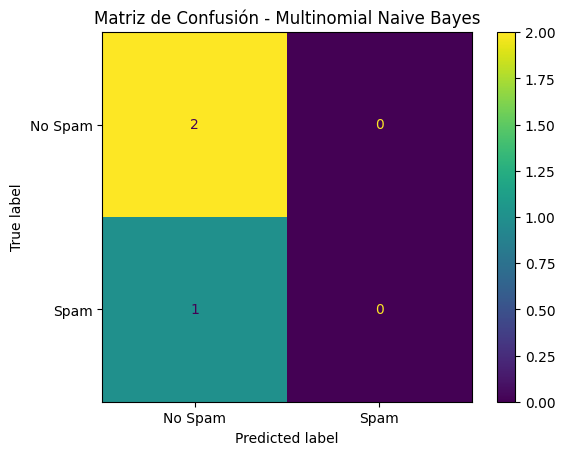

In [10]:
# Matriz de confusión

cm = confusion_matrix(
    y_test,
    y_pred
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Spam", "Spam"]
)


disp.plot()

plt.title(
    "Matriz de Confusión - Multinomial Naive Bayes"
)

plt.show()

# Reporte de Clasificación

El reporte de clasificación muestra el desempeño del modelo para cada clase individualmente.

Se analizan:

- Precision.
- Recall.
- F1-score.
- Número de muestras evaluadas.

In [11]:
# Reporte detallado

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Spam", "Spam"]
    )
)

              precision    recall  f1-score   support

     No Spam       0.67      1.00      0.80         2
        Spam       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Predicción de un Nuevo Mensaje

Finalmente, se prueba el modelo con un mensaje nuevo que no pertenece al conjunto de entrenamiento.

El texto es transformado utilizando el mismo vectorizador utilizado durante el entrenamiento y posteriormente clasificado por Multinomial Naive Bayes.

In [12]:
# Nuevo mensaje para clasificar

nuevo_mensaje = [
    "Felicitaciones ganaste un premio gratis"
]


# Transformación del texto

nuevo_vector = vectorizador.transform(
    nuevo_mensaje
)


# Predicción

prediccion = modelo.predict(
    nuevo_vector
)


if prediccion[0] == 1:
    resultado = "Spam"
else:
    resultado = "No Spam"


print("Mensaje:", nuevo_mensaje[0])
print("Clasificación:", resultado)

Mensaje: Felicitaciones ganaste un premio gratis
Clasificación: Spam


# Visualización de Distribución de Clases

Se representa gráficamente la cantidad de ejemplos disponibles para cada categoría del dataset.

Esta visualización permite observar el equilibrio entre las clases utilizadas durante el entrenamiento.

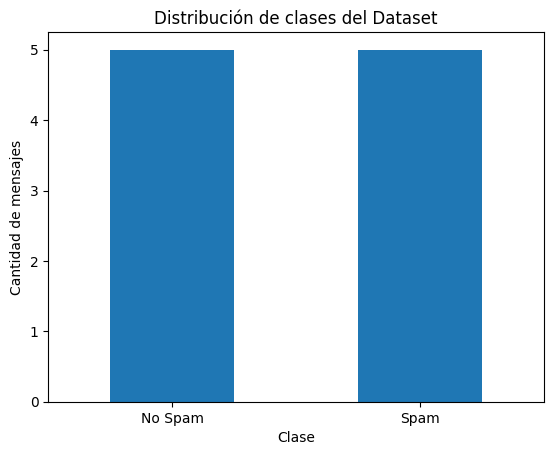

In [13]:
# Gráfico de distribución de clases

df["Clase"].value_counts().plot(
    kind="bar"
)


plt.xticks(
    [0,1],
    ["No Spam", "Spam"],
    rotation=0
)

plt.xlabel("Clase")
plt.ylabel("Cantidad de mensajes")

plt.title(
    "Distribución de clases del Dataset"
)

plt.show()

# Análisis de Resultados

El modelo Multinomial Naive Bayes fue entrenado utilizando mensajes de texto representados mediante frecuencias de palabras.

Los resultados obtenidos permiten observar que el algoritmo puede diferenciar correctamente entre mensajes Spam y No Spam utilizando únicamente la información estadística de aparición de términos.

La eficiencia del modelo se debe a que la distribución multinomial se adapta adecuadamente a datos representados como conteos de palabras.

Sin embargo, su rendimiento depende de la calidad de la representación del texto y del supuesto de independencia entre características.

# Conclusión

Multinomial Naive Bayes es un algoritmo eficiente para problemas de clasificación de texto debido a su simplicidad, rapidez de entrenamiento y bajo costo computacional.

Su aplicación en Procesamiento de Lenguaje Natural permite resolver problemas como detección de spam, clasificación de documentos y análisis de sentimientos.

Aunque presenta limitaciones relacionadas con la independencia entre características y la pérdida de información semántica, continúa siendo uno de los algoritmos más utilizados como modelo base en tareas de clasificación textual.